<a href="https://colab.research.google.com/github/M-R-spaghetti/SwiftDoc/blob/main/simple_cnn_firedataset_for_students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Acknowledgment
1) Mr. Ahmed Saied for prepared dataset, URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset/data

2) Ms. Mahsa Sanaei for educational notebook, URL: https://www.kaggle.com/code/snmahsa/simple-cnn-firedataset

https://drive.google.com/file/d/1YNzR-Pgo654scOwO_cpYmtEkaDXKd96f/view?usp=sharing

In [ ]:
!pip install --upgrade --quiet gdown
!gdown 1YNzR-Pgo654scOwO_cpYmtEkaDXKd96f -O fire_dataset.zip

Downloading...
From (original): https://drive.google.com/uc?id=1YNzR-Pgo654scOwO_cpYmtEkaDXKd96f
From (redirected): https://drive.google.com/uc?id=1YNzR-Pgo654scOwO_cpYmtEkaDXKd96f&confirm=t&uuid=92b39189-fea3-4335-81a7-cd959dffc0d3
To: /content/fire_dataset.zip
  2% 8.91M/406M [00:00<00:04, 88.2MB/s]

In [ ]:
!unzip -o fire_dataset.zip -d fire_dataset

In [ ]:
import glob
import os
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras import models,layers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle
import random

In [ ]:
# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED'] = '0' # Optional: for hash-based randomness

In [ ]:
def prepare_image(image):
  return cv2.resize(image, (32,32)) / 255.0

In [ ]:
def get_label(address):
  # Get the parent folder (directory) name
  parent_folder_name = os.path.basename(os.path.dirname(address))
  return parent_folder_name

In [ ]:
def label_encode_categorical(labels):
  encoder = LabelEncoder()
  encoder.fit(labels)
  return to_categorical(encoder.transform(labels)), encoder

In [ ]:
X_processed = []
X_original = []
labels = []
dataset_path = 'fire_dataset/fire_dataset'
for i , address in enumerate(glob.glob(dataset_path+'/**/*')):
  try:
    image_original = cv2.imread(address)
    image_processed = prepare_image(image_original)
    X_original.append(image_original)
    X_processed.append(image_processed)
    labels.append(get_label(address))
  except:
    print("Failed to load the image:", address)
  if i%100 == 0 :
    print(f"Progress: {i+1}")
print("Finished")
np_x = np.array(X_processed)

In [ ]:
import matplotlib.pyplot as plt

# Ensure the modified cell has been executed and X_original is populated
if not X_original:
    print("Start the previous cell")
else:
    # Get the indices for fire and non-fire images from the original labels
    fire_indices = [i for i, label in enumerate(labels) if label == 'fire_images']
    non_fire_indices = [i for i, label in enumerate(labels) if label == 'non_fire_images']

    # Select the first 5 indices for each category
    selected_fire_indices = fire_indices[:5]
    selected_non_fire_indices = non_fire_indices[:5]

    # Display the selected fire images
    print("Examples of photos with the fire (original quality):")
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(selected_fire_indices):
        # OpenCV reads images in BGR, matplotlib expects RGB
        img_rgb = cv2.cvtColor(X_original[idx], cv2.COLOR_BGR2RGB)
        plt.subplot(1, len(selected_fire_indices), i + 1)
        plt.imshow(img_rgb)
        plt.title(f"Label: {labels[idx]}")
        plt.axis('off')
    plt.show()

    # Display the selected non-fire images
    print("\nExamples of photos without the fire (original quality):")
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(selected_non_fire_indices):
        # OpenCV reads images in BGR, matplotlib expects RGB
        img_rgb = cv2.cvtColor(X_original[idx], cv2.COLOR_BGR2RGB)
        plt.subplot(1, len(selected_non_fire_indices), i + 1)
        plt.imshow(img_rgb)
        plt.title(f"Label: {labels[idx]}")
        plt.axis('off')
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Ensure the processed images are loaded
if np_x is None or len(np_x) == 0:
    print("Будь ласка, спочатку запустіть комірку для обробки зображень.")
else:
    # Get the indices for fire and non-fire images from the original labels
    fire_indices = [i for i, label in enumerate(labels) if label == 'fire_images']
    non_fire_indices = [i for i, label in enumerate(labels) if label == 'non_fire_images']

    # Select the first 5 indices for each category
    selected_fire_indices = fire_indices[:5]
    selected_non_fire_indices = non_fire_indices[:5]

    # Display the selected processed fire images
    print("Приклади фотографій з пожежею (оброблена якість):")
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(selected_fire_indices):
        plt.subplot(1, len(selected_fire_indices), i + 1)
        plt.imshow(np_x[idx])
        plt.title(f"Label: {labels[idx]}")
        plt.axis('off')
    plt.show()

    # Display the selected processed non-fire images
    print("\nПриклади фотографій без пожежі (оброблена якість):")
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(selected_non_fire_indices):
        plt.subplot(1, len(selected_non_fire_indices), i + 1)
        plt.imshow(np_x[idx])
        plt.title(f"Label: {labels[idx]}")
        plt.axis('off')
    plt.show()

In [ ]:
print("Unique labels:", set(labels))

In [ ]:
categ_labels, label_encoder=label_encode_categorical(labels)


In [ ]:
decoded_labels = label_encoder.inverse_transform(np.argmax(categ_labels, axis=1))


In [ ]:
print("Encoded Labels:", np.argmax(categ_labels, axis=1))
print("Decoded Labels:", decoded_labels)


In [ ]:
#Split
x_train, x_test, y_train, y_test =train_test_split(np_x, categ_labels, test_size=0.2,random_state=42)

In [ ]:
np_x.shape[1:]

In [ ]:
dim = np_x.shape[1:]
model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation = 'relu',input_shape=dim),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(32, (3,3), padding='same', activation = 'relu'),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(80,activation='relu'),
    layers.Dense(2,activation='softmax')]
)

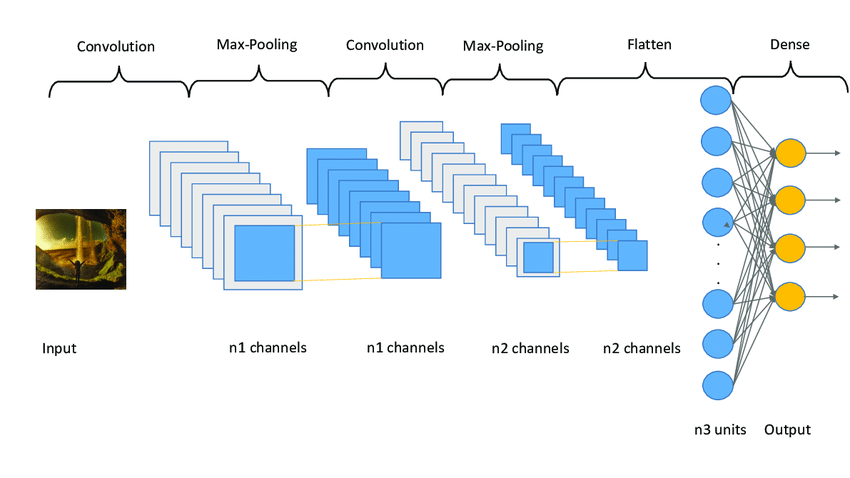



A sequential model using the Keras API with the following layers:
represents a convolutional layer in a neural network model. Here's a breakdown of the code:

This model consists of two convolutional layers followed by max pooling layers, a flattening layer, and two fully connected (dense) layers. It is suitable for classification tasks with two output classes.
```
dim = np_x.shape[1:]
model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation = 'relu',input_shape=dim),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(32, (3,3), padding='same', activation = 'relu'),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(80,activation='relu'),
    layers.Dense(2,activation='softmax')]
)
```
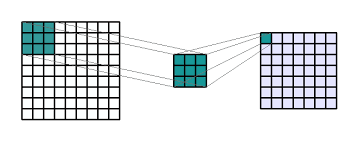

```
layers.Conv2D(32, (3,3), padding='same', activation = 'relu',input_shape=dim)
```

Conv2D: This is the class representing a 2D convolutional layer in Keras, which is commonly used in computer vision tasks for image processing.

`layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=dim)`: This is the first convolutional layer with 32 filters, a kernel size of 3x3, and ReLU activation. The `padding='same'` argument ensures that the output feature maps have the same spatial dimensions as the input. The `input_shape` parameter is set to `dim`, which represents the shape of a single input sample.

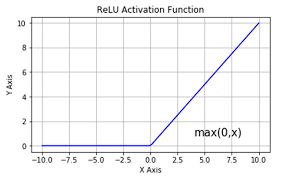

The Rectified Linear Unit (ReLU) is an activation function commonly used in neural networks. It is defined as follows:

```
ReLU(x) = max(0, x)
```

In other words, the ReLU function takes an input value `x` and returns the maximum of `0` and `x`. If the input `x` is positive or zero, the output is equal to `x`. If the input `x` is negative, the output is `0`.

The ReLU function introduces non-linearity to the network, allowing it to learn complex patterns and features in the data. It is computationally efficient and helps alleviate the vanishing gradient problem by allowing gradients to flow more easily during backpropagation.

ReLU is widely used as an activation function in various types of neural network layers, including convolutional layers, fully connected layers, and recurrent layers. It has proven to be effective in many deep learning applications, including image classification, object detection, and natural language processing.


```
layers.MaxPool2D((2,2))
```

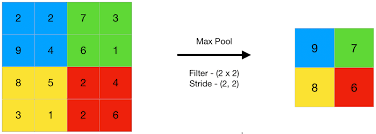

 represents a max pooling layer in a neural network model. Here's a breakdown of the code:

- `MaxPool2D`: This is the class representing the max pooling layer in Keras. Max pooling is a downsampling operation commonly used in convolutional neural networks (CNNs) for reducing the spatial dimensions of the input data.

- `2`: This parameter specifies the size of the max pooling window. In this case, a window of size 2x2 is used. During the pooling operation, the window slides over the input feature map and selects the maximum value within each window.

Max pooling helps in reducing the spatial dimensions of the feature maps while retaining the most salient features. It provides translation invariance to small spatial translations in the input data, making the model more robust to variations in the position of features.

By downsampling the feature maps, max pooling reduces the computational complexity of the network and helps in capturing higher-level features by summarizing local information. It also helps in controlling overfitting by introducing some degree of spatial invariance and reducing the sensitivity to small variations in the input.

Max pooling is typically applied after convolutional layers in CNN architectures, enabling the network to learn hierarchical representations of the input data.





In [ ]:

model.compile(loss='categorical_crossentropy', optimizer = 'SGD' , metrics = ['accuracy'])


In [ ]:
model.summary()

In [ ]:
result = model.fit(x_train, y_train, validation_data =(x_test, y_test ), epochs= 20 ,batch_size=32)

In [ ]:
import pandas as pd
pd.DataFrame(result.history).plot()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Get the indices for fire and non-fire images from the original labels
fire_indices = [i for i, label in enumerate(labels) if label == 'fire_images']
non_fire_indices = [i for i, label in enumerate(labels) if label == 'non_fire_images']

# Select the last 5 indices for each category
selected_fire_indices = fire_indices[-5:]
selected_non_fire_indices = non_fire_indices[-5:]

# Combine the selected indices
selected_indices = selected_fire_indices + selected_non_fire_indices

# Get the corresponding images and true labels
selected_images_processed = np_x[selected_indices]
selected_images_original = [X_original[i] for i in selected_indices]
selected_true_labels = [labels[i] for i in selected_indices]

# Make predictions using the trained model
predictions = model.predict(selected_images_processed)
predicted_labels = label_encoder.inverse_transform(np.argmax(predictions, axis=1))

# Display the images with predictions
print("Examples of predictions:")
plt.figure(figsize=(15, 10))
for i, idx in enumerate(selected_indices):
    plt.subplot(2, 5, i + 1)
    # OpenCV reads images in BGR, matplotlib expects RGB
    img_rgb = cv2.cvtColor(selected_images_original[i], cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(f"True: {labels[idx]}\nPred: {predicted_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Make predictions on the test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Get the class names from the label encoder
class_names = label_encoder.classes_

# Generate and print the classification report
print("Звіт класифікації:")
print(classification_report(y_test_classes, y_pred_classes, target_names=class_names))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculate the confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Get the class names from the label encoder
class_names = label_encoder.classes_

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()